In [124]:
from collections import Counter
from datasets import load_dataset, ClassLabel, Sequence
import itertools
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import re
from collections import Counter
import json
from dotenv import load_dotenv
import os

load_dotenv()

True

In [23]:
data = load_dataset("nlpaueb/finer-139")
data

DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'ner_tags'],
        num_rows: 900384
    })
    validation: Dataset({
        features: ['id', 'tokens', 'ner_tags'],
        num_rows: 112494
    })
    test: Dataset({
        features: ['id', 'tokens', 'ner_tags'],
        num_rows: 108378
    })
})

In [24]:
label_names = data["train"].features["ner_tags"].feature.names
print(len(label_names), label_names[:20])

279 ['O', 'B-AccrualForEnvironmentalLossContingencies', 'B-AcquiredFiniteLivedIntangibleAssetsWeightedAverageUsefulLife', 'I-AcquiredFiniteLivedIntangibleAssetsWeightedAverageUsefulLife', 'B-AllocatedShareBasedCompensationExpense', 'B-AmortizationOfFinancingCosts', 'B-AmortizationOfIntangibleAssets', 'I-AmortizationOfIntangibleAssets', 'B-AntidilutiveSecuritiesExcludedFromComputationOfEarningsPerShareAmount', 'I-AntidilutiveSecuritiesExcludedFromComputationOfEarningsPerShareAmount', 'B-AreaOfRealEstateProperty', 'I-AreaOfRealEstateProperty', 'B-AssetImpairmentCharges', 'B-BusinessAcquisitionEquityInterestsIssuedOrIssuableNumberOfSharesIssued', 'B-BusinessAcquisitionPercentageOfVotingInterestsAcquired', 'I-BusinessAcquisitionPercentageOfVotingInterestsAcquired', 'B-BusinessCombinationAcquisitionRelatedCosts', 'B-BusinessCombinationConsiderationTransferred1', 'B-BusinessCombinationContingentConsiderationLiability', 'B-BusinessCombinationRecognizedIdentifiableAssetsAcquiredAndLiabilitiesA

In [25]:
label_counts = Counter(itertools.chain.from_iterable(data["train"]["ner_tags"]))
label_counts_named = Counter({label_names[i]: c for i, c in label_counts.items()})

C:\Users\Admin\AppData\Local\Temp\ipykernel_16676\1554119968.py:30: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


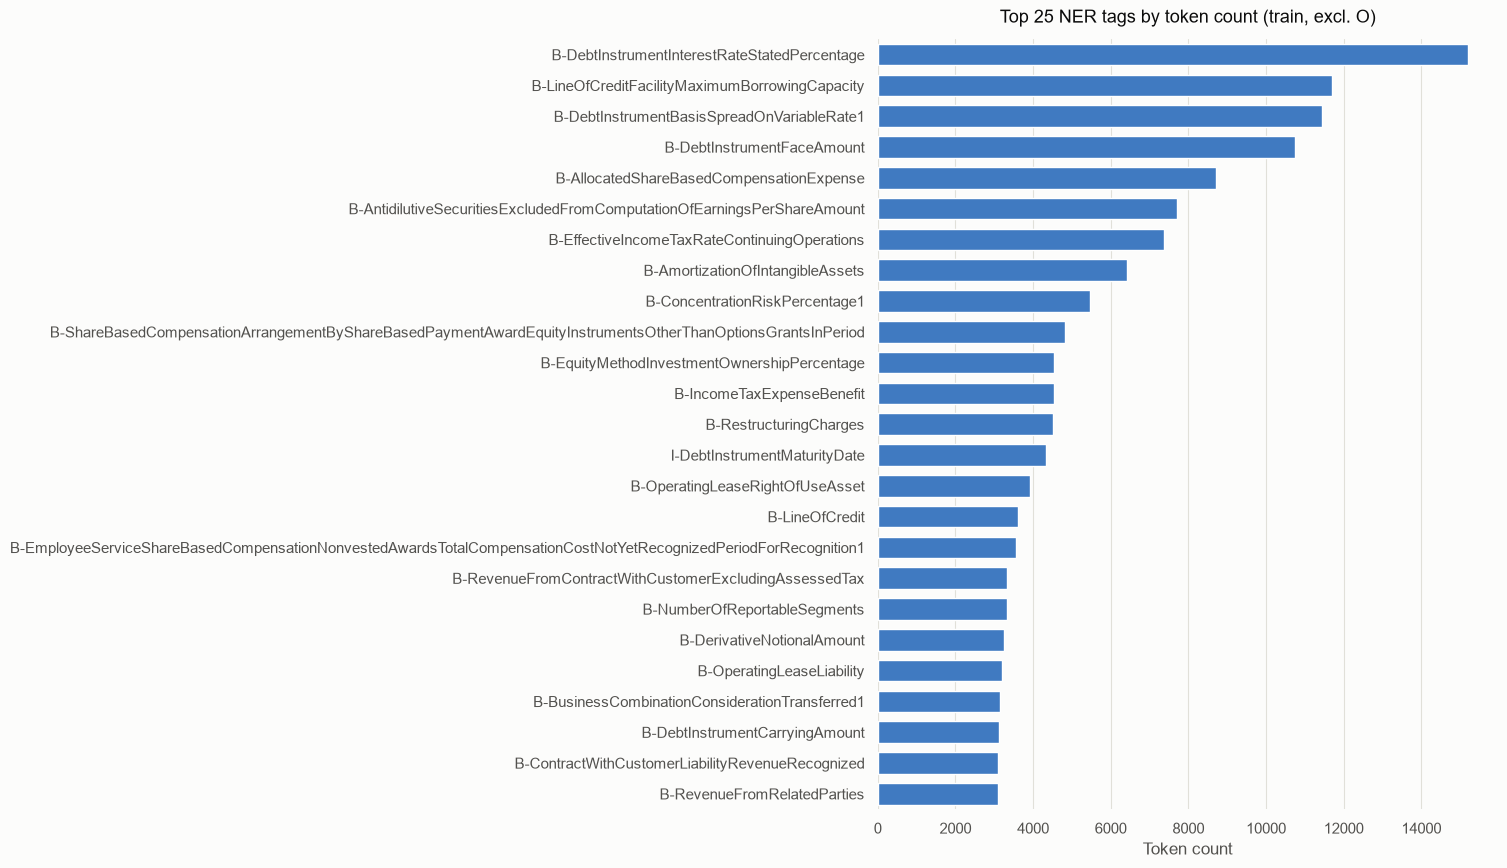

In [37]:
# "O" dwarfs every entity tag by orders of magnitude, so it's excluded here
# to see the actual entity-type distribution. Re-add it if you want the full picture.
top_n = 25
top_labels = [
    (label, count) for label, count in label_counts_named.most_common() if label != "O"
][:top_n]

df = pd.DataFrame(top_labels, columns=["label", "count"])

sns.set_theme(style="whitegrid", palette="pastel")
fig, ax = plt.subplots(figsize=(8, 10))
ax.set_facecolor("#fcfcfb")
fig.patch.set_facecolor("#fcfcfb")

sns.barplot(data=df, y="label", x="count", color="#2a78d6", ax=ax, width=0.7)

ax.set_title(
    f"Top {top_n} NER tags by token count (train, excl. O)",
    color="#0b0b0b",
    fontsize=13,
    pad=12,
)
ax.set_xlabel("Token count", color="#52514e")
ax.set_ylabel("")
ax.tick_params(colors="#52514e")
ax.grid(axis="x", color="#e1e0d9", linewidth=0.8)
ax.set_axisbelow(True)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

In [73]:
# Strip the BIO prefix to get the underlying XBRL concept names (should be 139 unique)
base_concepts = list(
    dict.fromkeys(name.split("-", 1)[1] for name in label_names if name != "O")
)
print(len(base_concepts))


# Checked first, before any keyword rule — cases where the tag name
# is structurally misleading relative to its real XBRL value type.
MANUAL_OVERRIDES = {
    "CumulativeEffectOfNewAccountingPrincipleInPeriodOfAdoption": "MONETARY_AMOUNT",
    "ShareBasedCompensationArrangementByShareBasedPaymentAwardEquityInstrumentsOtherThanOptionsGrantsInPeriod": "NUMBER",
    "ShareBasedCompensationArrangementByShareBasedPaymentAwardOptionsGrantsInPeriodGross": "NUMBER",
    "AntidilutiveSecuritiesExcludedFromComputationOfEarningsPerShareAmount": "NUMBER",
}


def is_date(name: str) -> bool:
    # anchored to the end: catches MaturityDate/MaturityDate1, not ...GrantDateFairValue
    return bool(re.search(r"Date\d*$", name))


def is_duration(name: str) -> bool:
    # exclude timing qualifiers that shadow the real value type (LongTermDebt, ...InPeriod, ...AtPeriodEnd)
    if re.search(r"InPeriod|DuringPeriod|PeriodEnd|PeriodOf|LongTerm|ShortTerm", name):
        return False
    return any(
        kw in name
        for kw in [
            "Term",
            "UsefulLife",
            "Life",
            "Duration",
            "Period",
            "Years",
            "Months",
            "Days",
        ]
    )


def is_percentage(name: str) -> bool:
    return any(kw in name for kw in ["Percentage", "PercentOf", "Percent", "Rate"])


def is_number(name: str) -> bool:
    # widened "NumberOf" -> "Number" to catch suffix cases (...ClaimsNumber, ...NonvestedNumber)
    # "Area" folded in here too, too rare (1 concept) to justify its own class
    return any(
        kw in name
        for kw in [
            "Number",
            "Shares",
            "Employees",
            "Units",
            "Counterparties",
            "Segments",
            "Votes",
            "Area",
        ]
    )


def is_monetary(name: str) -> bool:
    return any(
        kw in name
        for kw in [
            "Price",
            "Cost",
            "Revenue",
            "Income",
            "Expense",
            "Payment",
            "Asset",
            "Liabilit",
            "Value",
            "Amount",
            "Compensation",
            "Charge",
            "Proceeds",
            "Deposit",
            "Investment",
            "Loss",
            "Gain",
            "Cash",
            "Debt",
            "Equity",
            "Capital",
            "Fee",
            "Tax",
            "Dividend",
            "Contribution",
            "Award",
            "Obligation",
            "Balance",
            "Consideration",
            "Reserve",
            "Fund",
            "Premium",
            "Discount",
            "Royalt",
            "Rent",
            "Financing",
            "Impairment",
            "Amortization",
            "Depreciation",
            "Accru",
            "PerShare",
            "Goodwill",
            "Credit",
        ]
    )


BUCKET_RULES = [
    ("DATE", is_date),
    ("DURATION", is_duration),
    ("PERCENTAGE", is_percentage),
    ("NUMBER", is_number),
    ("MONETARY_AMOUNT", is_monetary),
]


def bucket_concept(name: str) -> str:
    if name in MANUAL_OVERRIDES:
        return MANUAL_OVERRIDES[name]
    for bucket, match_fn in BUCKET_RULES:
        if match_fn(name):
            return bucket
    return "OTHER"


concept_to_bucket = {c: bucket_concept(c) for c in base_concepts}
bucket_counts = Counter(concept_to_bucket.values())
bucket_counts.most_common()

139


[('MONETARY_AMOUNT', 86),
 ('NUMBER', 21),
 ('PERCENTAGE', 21),
 ('DURATION', 10),
 ('DATE', 1)]

In [86]:
old_label_names = data["train"].features["ner_tags"].feature.names  # 279 strings

coarse_types = ["MONETARY_AMOUNT", "PERCENTAGE", "NUMBER", "DATE", "DURATION"]
new_label_names = ["O"] + [f"{p}-{t}" for t in coarse_types for p in ("B", "I")]
new_label2id = {name: i for i, name in enumerate(new_label_names)}

old_id_to_new_id = {}
for old_id, old_name in enumerate(old_label_names):
    if old_name == "O":
        old_id_to_new_id[old_id] = new_label2id["O"]
        continue
    prefix, concept = old_name.split("-", 1)
    bucket = concept_to_bucket.get(concept)  # your finished dict from step 1
    old_id_to_new_id[old_id] = (
        new_label2id[f"{prefix}-{bucket}"] if bucket else new_label2id["O"]
    )


def remap_tags(example):
    example["ner_tags"] = [old_id_to_new_id[t] for t in example["ner_tags"]]
    return example


new_features = data["train"].features.copy()
new_features["ner_tags"] = Sequence(ClassLabel(names=new_label_names))

ds_remapped = data.map(remap_tags, features=new_features)

Map:   0%|          | 0/900384 [00:00<?, ? examples/s]

Map: 100%|██████████| 108378/108378 [00:03<00:00, 27350.36 examples/s]


In [ ]:
# --- Safety net 1: proper-ish detokenization ---
# FiNER tokens are pre-split, naive " ".join() creates ugly spacing before
# punctuation ("30 , 2015" instead of "30, 2015"). Fixing this matters because
# whatever spacing convention you train on is what the model expects at
# inference time, and real extracted document text won't have this artifact.
NO_SPACE_BEFORE = {",", ".", ")", "]", "}", ":", ";"}


def join_tokens(tokens):
    text = ""
    for i, tok in enumerate(tokens):
        if i > 0 and tok not in NO_SPACE_BEFORE:
            text += " "
        text += tok
    return text


# --- Safety net 2: defensive BIO parsing ---
# Groups consecutive B-/I- tokens into full entity spans. Falls back to
# starting a fresh entity (instead of crashing) if it ever hits a malformed
# I- tag with no preceding B- — shouldn't happen on FiNER's well-formed
# labels, but cheap insurance against a bad edge case silently killing a run.
def extract_entities(tokens, tag_ids, id2label):
    entities = []
    current_type, current_tokens = None, []

    def flush():
        if current_type:
            entities.append({"type": current_type, "text": join_tokens(current_tokens)})

    for token, tag_id in zip(tokens, tag_ids):
        tag = id2label[tag_id]
        if tag == "O":
            flush()
            current_type, current_tokens = None, []
        elif tag.startswith("B-"):
            flush()
            current_type, current_tokens = tag[2:], [token]
        elif tag.startswith("I-") and tag[2:] == current_type:
            current_tokens.append(token)
        else:  # I- with no matching B- — start fresh rather than crash
            flush()
            current_type, current_tokens = tag[2:], [token]
    flush()
    return entities


# --- Build the chat-formatted example ---
SYSTEM_PROMPT = (
    "You are a financial entity extraction assistant. Given a sentence from a "
    "financial document, extract entities and respond with a compact JSON list "
    'of {"type": ..., "text": ...} objects. If no entities are found, respond with [].'
)


def build_example(example, id2label):
    sentence = join_tokens(example["tokens"])
    entities = extract_entities(example["tokens"], example["ner_tags"], id2label)
    return {
        "messages": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {
                "role": "user",
                "content": f"Extract financial entities from: '{sentence}'",
            },
            {
                "role": "assistant",
                "content": json.dumps(entities, separators=(",", ":")),
            },
        ]
    }


id2label = {i: name for i, name in enumerate(new_label_names)}

text_dataset = ds_remapped.map(
    lambda ex: build_example(ex, id2label),
    remove_columns=ds_remapped["train"].column_names,
)

Map: 100%|██████████| 108378/108378 [00:08<00:00, 13297.45 examples/s]


0 / 900384 examples have an entity not found in its source sentence


In [126]:
text_dataset.push_to_hub("AG2307/financial-ner-llm-data", private=True)

Creating parquet from Arrow format: 100%|██████████| 451/451 [00:00<00:00, 761.89ba/s]
Processing Files (1 / 1): 100%|██████████| 53.0MB / 53.0MB, 2.89MB/s  
New Data Upload: 100%|██████████| 53.0MB / 53.0MB, 2.89MB/s  
Creating parquet from Arrow format: 100%|██████████| 451/451 [00:00<00:00, 836.94ba/s]
Processing Files (1 / 1): 100%|██████████| 54.5MB / 54.5MB, 2.95MB/s  
New Data Upload: 100%|██████████| 54.5MB / 54.5MB, 2.95MB/s  
Creating parquet from Arrow format: 100%|██████████| 113/113 [00:00<00:00, 646.99ba/s]
Processing Files (1 / 1): 100%|██████████| 14.1MB / 14.1MB, 1.08MB/s  
New Data Upload: 100%|██████████| 14.1MB / 14.1MB, 1.08MB/s  
Creating parquet from Arrow format: 100%|██████████| 109/109 [00:00<00:00, 670.88ba/s]
Processing Files (1 / 1): 100%|██████████| 13.6MB / 13.6MB, 1.07MB/s  
New Data Upload: 100%|██████████| 13.6MB / 13.6MB, 1.07MB/s  
Uploading the dataset shards: 100%|██████████| 1/1 [00:04<00:00,  4.03s/it]


CommitInfo(commit_url='https://huggingface.co/datasets/AG2307/financial-ner-llm-data/commit/96bb9c5fa1219f50c4f023656f755f880fb5cd9d', commit_message='Upload dataset', commit_description='', oid='96bb9c5fa1219f50c4f023656f755f880fb5cd9d', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/AG2307/financial-ner-llm-data', endpoint='https://huggingface.co', repo_type='dataset', repo_id='AG2307/financial-ner-llm-data'), pr_revision=None, pr_num=None)